# 06 Combining gravity and magnetics: Poisson analysis

For a body with uniform density rho and magnetisation M, Poisson's
relation holds point by point at the pole:

    T_pole = Cm M / (G rho) * dg/dz

So where gravity and magnetics come from the same body, the reduced-to-pole
TMI is proportional to the first vertical derivative of gravity. A linear
regression of T_pole against dg/dz in a moving window gives (Chandler and
Malek 1991):

    slope         Cm M / (G rho): the magnetisation to density ratio
    correlation   how well the two fields share a source (near +-1) or not (near 0)
    intercept     regional offset

`transforms.poisson_analysis` does the RTP, regrids the magnetics onto the
gravity geometry, takes dg/dz and runs the regression. Its `m_over_rho`
output converts the slope to (A/m) per (kg/m^3).

Resolution: the gravity grid is 400 m, the TMI 80 m. Low-pass the RTP to
about two gravity cells before regridding so the regression compares like
with like. Window size sets the trade-off between spatial resolution and
stability; 15 cells is 6 km here.

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from potfield import read_grid, write_grid, filters, transforms, spectrum, display

DATA = "../data"
OUT = "../outputs"
INC, DEC = -62.4, 7.5   # IGRF inclination, declination (deg) for the Frome area at 2015.0
plt.rcParams["figure.dpi"] = 90

In [2]:
cba = read_grid(f"{DATA}/frome_cba.ers", bounds=(139.20, -30.75, 139.95, -30.05), epsg=28354, units="mGal")
tmi = read_grid(f"{DATA}/frome_tmi.ers", epsg=28354, units="nT")
print(cba); print(tmi)
rtp = transforms.reduce_to_pole(tmi, INC, DEC)
rtp_lp = filters.butterworth_lowpass(rtp, 2 * cba.dx)
res = transforms.poisson_analysis(cba, rtp_lp, window=15, magnetics_is_rtp=True)

Grid('frome_cba', 183x170, cell 430.067x430.067 m (~430x430 m), EPSG:28354, bounds W326262.4052 S6596736.4295 E399373.8654 N6675438.7660, units 'mGal')
Grid('frome_tmi', 913x849, cell 86.0126x86.0126 m (~86x86 m), EPSG:28354, bounds W326468.6768 S6596700.2018 E399493.3994 N6675229.7326, units 'nT')


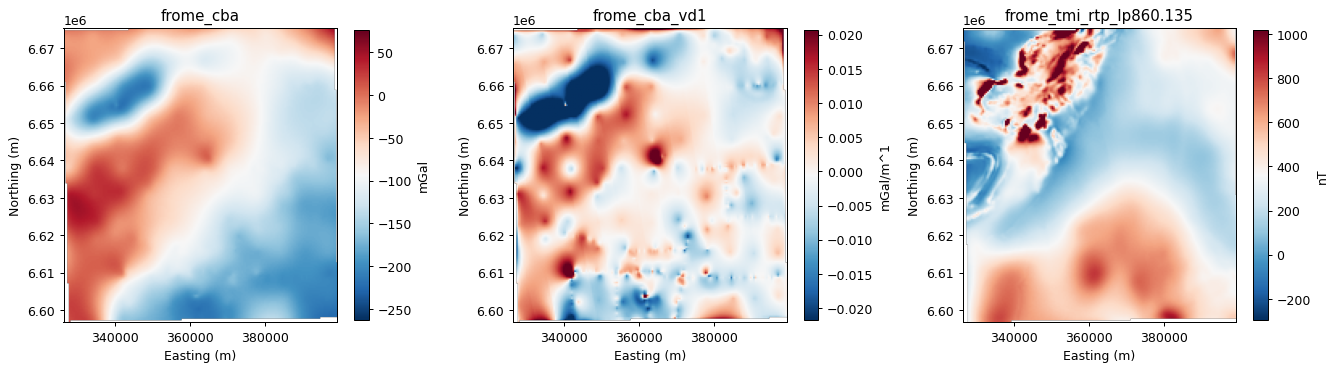

In [3]:
gz = filters.vertical_derivative(cba, 1)
rtp_on_grav = rtp_lp.regrid(cba)
fig, axes = display.compare([cba, gz, rtp_on_grav], ncols=3, cmap="RdBu_r", clip=("std", 2.5), figsize_per=(5, 4.5))

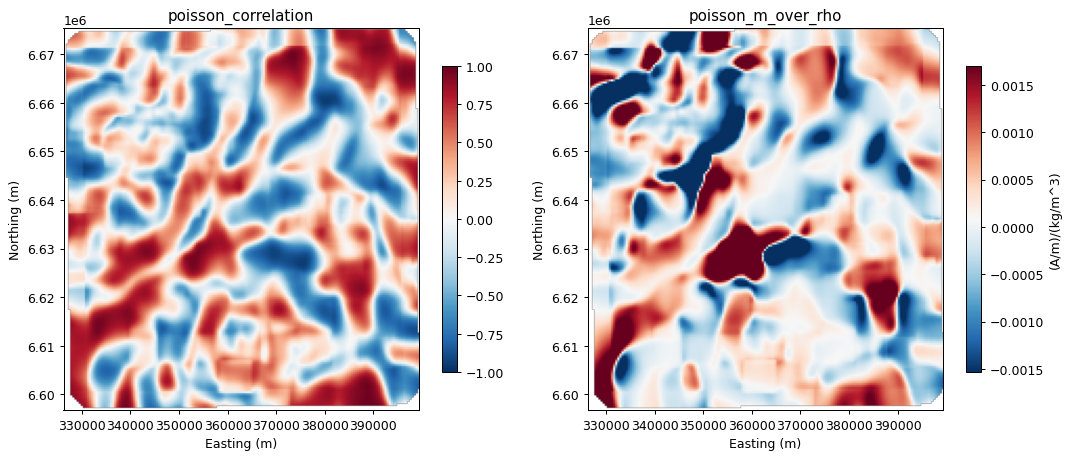

In [4]:
fig, axes = display.compare([res["correlation"], res["m_over_rho"]], ncols=2, cmap="RdBu_r", clip=(-1, 1), figsize_per=(6, 5))
axes[0, 1].images[0].set_clim(*display.clip_limits(res["m_over_rho"].values, "pct", 5))

Reading the maps: high positive correlation with a stable ratio marks bodies
that are both dense and magnetic (mafic intrusions, iron-rich
metasediments). Correlation near zero marks sources present in only one
field, such as non-magnetic dense rocks or magnetic but light rocks.
Negative correlation with a good fit points to a body that is magnetic
and less dense, or to remanence that RTP did not correct.

Text(0.5, 1.0, 'all cells, coloured by local correlation')

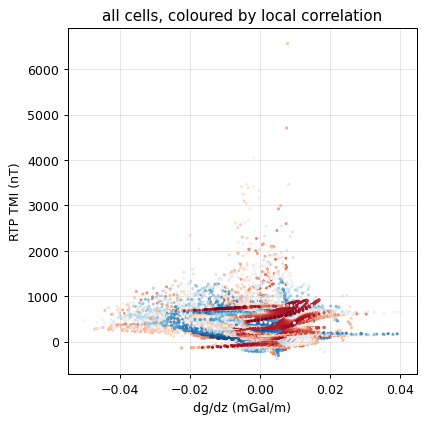

In [5]:
ok = np.isfinite(gz.values) & np.isfinite(rtp_on_grav.values)
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(gz.values[ok], rtp_on_grav.values[ok], s=2, c=res["correlation"].values[ok], cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xlabel("dg/dz (mGal/m)"); ax.set_ylabel("RTP TMI (nT)"); ax.grid(alpha=0.3)
ax.set_title("all cells, coloured by local correlation")

## Pseudogravity against observed gravity

The other way round: transform the magnetics to pseudogravity and compare
it with the Bouguer anomaly directly. The two should agree in shape where
the sources are common; the amplitude ratio is again rho / M.

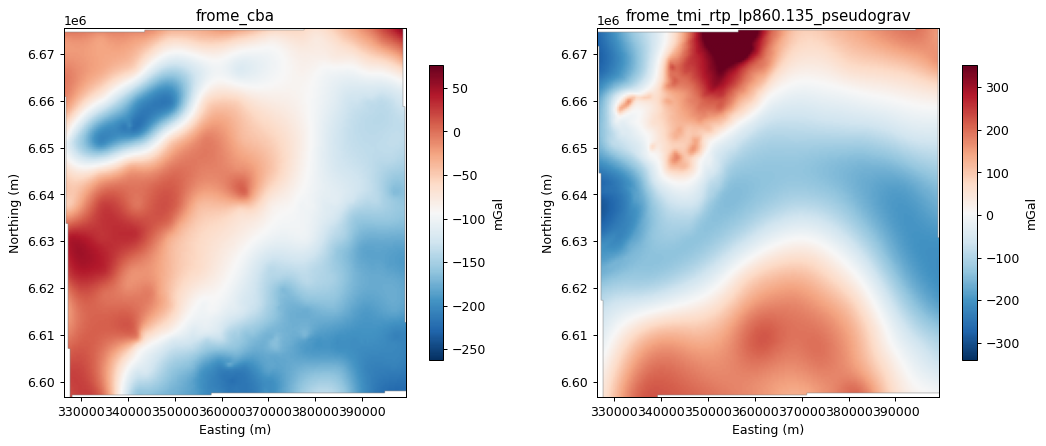

In [6]:
pg = transforms.pseudogravity(rtp_lp, 90, 0).regrid(cba)   # already at the pole, so I=90
fig, axes = display.compare([cba, pg], ncols=2, cmap="RdBu_r", clip=("std", 2.5))

In [7]:
import os
os.makedirs(OUT, exist_ok=True)
for key in ("correlation", "m_over_rho"):
    write_grid(res[key], f"{OUT}/poisson_{key}.grd")